# **FACE AGING GAN — TESTING ON AgeDB**

Pipeline: Mount → Install → Load AgeDB (pairs format) → Define architecture → Load checkpoint → Generate → Visualize → CSIM + FID evaluation.

## 1. Mount Drive & Install

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q facenet-pytorch torch-fidelity torchvision timm tqdm
!pip install -q Pillow==10.2.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 820.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2

## 2. Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.ndimage import gaussian_filter
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models import ResNet50_Weights, VGG16_Weights, Inception_V3_Weights
from torchvision.utils import save_image
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cpu


## 3. Config

In [ ]:
# ── Must match training exactly ──────────────────────────────
IMG_SIZE     = 128
STYLE_DIM    = 256
IDENTITY_DIM = 512
NUM_CLASSES  = 8
BATCH_SIZE   = 16

BASE_PATH    = '/content/drive/MyDrive/FaceAgingProject'
MODEL_PATH   = f'{BASE_PATH}/final_models/final_model_epoch70.pth'

# AgeDB paths  ← same as your old testing file
AGEDB_PATH   = '/content/drive/MyDrive/agedb_30_112x112/'
PAIRS_FILE   = '/content/drive/MyDrive/agedb_30_ann.txt'
RESULTS_PATH = f'{BASE_PATH}/test_results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

# Age groups — identical to training
AGE_GROUPS = {
    0: (0,   10,  '0-10'),
    1: (11,  20,  '11-20'),
    2: (21,  30,  '21-30'),
    3: (31,  40,  '31-40'),
    4: (41,  50,  '41-50'),
    5: (51,  60,  '51-60'),
    6: (61,  70,  '61-70'),
    7: (71, 120,  '71+'),
}
AGE_LABELS = [v[2] for v in AGE_GROUPS.values()]

print('Config loaded.')
# Quick sanity-check: list first 5 files in AgeDB folder
files = os.listdir(AGEDB_PATH)
print(f'AgeDB folder — total files : {len(files)}')
print(f'First 5                    : {files[:5]}')

Config loaded.
AgeDB folder — total files : 12000
First 5                    : ['9110.bmp', '911.bmp', '9113.bmp', '9109.bmp', '9114.bmp']


## 4. Preprocessing — Same as Training `val_transform`

In [ ]:
# Matches training val_transform exactly (no augmentation)
test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

def load_image(path):
    # Load one image -> tensor (3, H, W) in [-1, 1]
    img = Image.open(path).convert('RGB')
    return test_transform(img)

def denorm(t):
    # [-1,1] tensor (B,3,H,W) -> numpy (B,H,W,3) in [0,1]
    t = (t * 0.5 + 0.5).clamp(0, 1)
    return t.permute(0, 2, 3, 1).cpu().numpy()

print('Transforms ready.')


Transforms ready.


## 5. AgeDB Dataset

Uses the **pairs-file format** from your original testing file: each line has `label img1 img2`. We load all unique images from those pairs.

In [ ]:
class AgeDBDataset(Dataset):
    """
    Reads the AgeDB pairs annotation file (3-column format: label img1 img2).
    Collects every unique image that exists on disk.
    Returns (image_tensor, filename) per item.
    """
    def __init__(self, agedb_path, pairs_file, max_samples=500, transform=None):
        self.agedb_path = agedb_path
        self.transform  = transform
        self.samples    = []

        available = set(os.listdir(agedb_path))

        seen = set()
        with open(pairs_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 3:
                    continue
                # format: label  img1_path  img2_path
                for img_field in parts[1:]:
                    fname = img_field.split('/')[-1]   # basename only
                    if fname in seen:
                        continue
                    seen.add(fname)
                    if fname in available:
                        self.samples.append(fname)

                if len(self.samples) >= max_samples:
                    break

        print(f'AgeDB unique images found : {len(self.samples)}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname = self.samples[idx]
        path  = os.path.join(self.agedb_path, fname)
        img   = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img.float(), fname


agedb_dataset = AgeDBDataset(
    AGEDB_PATH, PAIRS_FILE,
    max_samples=500,
    transform=test_transform
)
agedb_loader = DataLoader(
    agedb_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
print(f'Batches : {len(agedb_loader)}')

AgeDB unique images found : 500
Batches : 32


## 6. Define Architecture

Exact copy from `TRAINING_V5.ipynb` — every class name and constructor signature must match for `load_state_dict` to work.

In [ ]:
# ── AdaIN ──────────────────────────────────────────────────
class AdaIN(nn.Module):
    def __init__(self, num_features, style_dim):
        super().__init__()
        self.norm       = nn.InstanceNorm2d(num_features, affine=False)
        self.style_proj = nn.Linear(style_dim, num_features * 2)

    def forward(self, x, style):
        x_norm      = self.norm(x)
        gamma, beta = self.style_proj(style).chunk(2, dim=1)
        gamma       = gamma.unsqueeze(-1).unsqueeze(-1)
        beta        = beta.unsqueeze(-1).unsqueeze(-1)
        return gamma * x_norm + beta


# ── Attention Gate ─────────────────────────────────────────
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g  = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=True),
                                  nn.InstanceNorm2d(F_int))
        self.W_x  = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=True),
                                  nn.InstanceNorm2d(F_int))
        self.psi  = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=True),
                                  nn.InstanceNorm2d(1),
                                  nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:],
                               mode='bilinear', align_corners=False)
        return x * self.psi(self.relu(g1 + x1))


# ── ResBlock ───────────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, channels, style_dim=None):
        super().__init__()
        self.conv1     = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.conv2     = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.use_adain = style_dim is not None
        if self.use_adain:
            self.adain1 = AdaIN(channels, style_dim)
            self.adain2 = AdaIN(channels, style_dim)
        else:
            self.norm1  = nn.InstanceNorm2d(channels)
            self.norm2  = nn.InstanceNorm2d(channels)
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, style=None):
        res = x
        if self.use_adain and style is not None:
            out = self.act(self.adain1(self.conv1(x), style))
            out = self.adain2(self.conv2(out), style)
        else:
            out = self.act(self.norm1(self.conv1(x)))
            out = self.norm2(self.conv2(out))
        return self.act(out + res)


# ── EncBlock ───────────────────────────────────────────────
class EncBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x): return self.block(x)

print('Building blocks defined.')

Building blocks defined.


In [ ]:
# -- FaceEncoder --
class FaceEncoder(nn.Module):
    # ResNet50 backbone -> (content_feat (B,256,H/16,W/16), identity_feat (B,512))
    def __init__(self):
        super().__init__()
        bb = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        self.layer0 = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1 = bb.layer1
        self.layer2 = bb.layer2
        self.layer3 = bb.layer3
        self.content_head = nn.Sequential(
            nn.Conv2d(1024, 512, 1, bias=False), nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512,  256, 1, bias=False), nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.identity_head = nn.Sequential(
            bb.layer4, bb.avgpool, nn.Flatten(),
            nn.Linear(2048, 512), nn.BatchNorm1d(512),
        )

    def forward(self, x):
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.content_head(x), self.identity_head(x)


# -- ArcFaceNet (frozen - identity verification only) --
class ArcFaceNet(nn.Module):
    def __init__(self):
        super().__init__()
        bb = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(
            bb.conv1, bb.bn1, bb.relu, bb.maxpool,
            bb.layer1, bb.layer2, bb.layer3, bb.layer4, bb.avgpool,
        )
        self.flatten = nn.Flatten()
        self.embed   = nn.Linear(2048, IDENTITY_DIM)
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        return F.normalize(
            self.embed(self.flatten(self.features(x))), dim=1)

print('FaceEncoder, ArcFaceNet defined.')


FaceEncoder, ArcFaceNet defined.


In [ ]:
# -- AgeEmbedder --
# (age_group_label: LongTensor, identity_vec: (B,512)) -> style (B,256)
class AgeEmbedder(nn.Module):
    def __init__(self, num_classes, identity_dim, style_dim):
        super().__init__()
        self.age_embed = nn.Embedding(num_classes, 64)
        in_dim = 64 + identity_dim
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 512), nn.LayerNorm(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 512),    nn.LayerNorm(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, style_dim), nn.LayerNorm(style_dim),
        )

    def forward(self, age_label, identity_vec):
        return self.mlp(
            torch.cat([self.age_embed(age_label), identity_vec], dim=1))

print('AgeEmbedder defined.')


AgeEmbedder defined.


In [ ]:
# ── Generator (UNet + AdaIN + Attention) ──────────────────
class Generator(nn.Module):
    def __init__(self, style_dim=STYLE_DIM):
        super().__init__()
        self.style_dim = style_dim

        self.enc1 = EncBlock(3,   64)
        self.enc2 = EncBlock(64,  128)
        self.enc3 = EncBlock(128, 256)
        self.enc4 = EncBlock(256, 512)

        self.bottleneck = nn.ModuleList([
            ResBlock(512, style_dim),
            ResBlock(512, style_dim),
            ResBlock(512, style_dim),
        ])

        self.att4 = AttentionGate(F_g=512, F_l=256, F_int=128)
        self.att3 = AttentionGate(F_g=256, F_l=128, F_int=64)
        self.att2 = AttentionGate(F_g=128, F_l=64,  F_int=32)
        self.att1 = AttentionGate(F_g=64,  F_l=64,  F_int=32)

        self.conv4 = nn.Conv2d(768, 256, 3, padding=1, bias=False)
        self.norm4 = nn.InstanceNorm2d(256)
        self.ada4  = AdaIN(256, style_dim)

        self.conv3 = nn.Conv2d(384, 128, 3, padding=1, bias=False)
        self.norm3 = nn.InstanceNorm2d(128)
        self.ada3  = AdaIN(128, style_dim)

        self.conv2 = nn.Conv2d(192, 64,  3, padding=1, bias=False)
        self.norm2 = nn.InstanceNorm2d(64)
        self.ada2  = AdaIN(64, style_dim)

        self.conv1 = nn.Conv2d(128, 32,  3, padding=1, bias=False)
        self.norm1 = nn.InstanceNorm2d(32)
        self.ada1  = AdaIN(32, style_dim)

        self.act = nn.LeakyReLU(0.2, inplace=True)

        self.out_conv = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1, bias=False),
            nn.InstanceNorm2d(16),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(16, 3, 1),
            nn.Tanh()
        )

    @staticmethod
    def _up(x, target):
        return F.interpolate(x, size=target.shape[2:],
                             mode='bilinear', align_corners=False)

    def forward(self, x, style):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        b = e4
        for res in self.bottleneck:
            b = res(b, style)

        d4 = self._up(b, e3)
        s4 = self.att4(d4, e3)
        d4 = self.act(self.norm4(self.conv4(torch.cat([d4, s4], dim=1))))
        d4 = self.ada4(d4, style)

        d3 = self._up(d4, e2)
        s3 = self.att3(d3, e2)
        d3 = self.act(self.norm3(self.conv3(torch.cat([d3, s3], dim=1))))
        d3 = self.ada3(d3, style)

        d2 = self._up(d3, e1)
        s2 = self.att2(d2, e1)
        d2 = self.act(self.norm2(self.conv2(torch.cat([d2, s2], dim=1))))
        d2 = self.ada2(d2, style)

        d1  = self._up(d2, x)
        e1u = self._up(e1, x)
        s1  = self.att1(d1, e1u)
        d1  = self.act(self.norm1(self.conv1(torch.cat([d1, s1], dim=1))))
        d1  = self.ada1(d1, style)

        return self.out_conv(d1)

# Shape check
with torch.no_grad():
    _g = Generator()
    _o = _g(torch.randn(2, 3, 128, 128), torch.randn(2, STYLE_DIM))
    assert _o.shape == (2, 3, 128, 128), f'Bad shape: {_o.shape}'
    print(f'Generator output: {_o.shape}  ✔')
del _g, _o

Generator output: torch.Size([2, 3, 128, 128])  ✔


## 7. Instantiate & Load Checkpoint

In [ ]:
encoder      = FaceEncoder().to(device)
arcface      = ArcFaceNet().to(device)
age_embedder = AgeEmbedder(NUM_CLASSES, IDENTITY_DIM, STYLE_DIM).to(device)
G            = Generator(STYLE_DIM).to(device)

arcface.eval()   # always frozen

checkpoint = torch.load(MODEL_PATH, map_location=device)
encoder.load_state_dict(checkpoint['encoder'])
age_embedder.load_state_dict(checkpoint['age_embedder'])
G.load_state_dict(checkpoint['G'])

encoder.eval()
age_embedder.eval()
G.eval()

if 'total_epochs' in checkpoint:
    print(f'Checkpoint trained for {checkpoint["total_epochs"]} epochs.')
print('✅ All weights loaded.')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 82.9MB/s]


Checkpoint trained for 70 epochs.
✅ All weights loaded.


## 8. Generate Aged Images

For every AgeDB image we generate a version aged to the **oldest group (71+)**. Real and aged arrays are stored for evaluation.

In [ ]:
all_real   = []   # numpy (N, H, W, 3) in [0,1]
all_aged   = []
all_fnames = []

TARGET_GROUP = 7   # 71+  ← change if you want a different target

encoder.eval()
age_embedder.eval()
G.eval()

with torch.no_grad():
    for imgs, fnames in tqdm(agedb_loader, desc='Generating aged images'):
        imgs  = imgs.to(device)
        B     = imgs.size(0)

        tgt       = torch.full((B,), TARGET_GROUP,
                               dtype=torch.long, device=device)
        _, id_vec = encoder(imgs)
        style     = age_embedder(tgt, id_vec)
        aged      = G(imgs, style)

        all_real.extend(denorm(imgs))
        all_aged.extend(denorm(aged))
        all_fnames.extend(fnames)

all_real   = np.array(all_real)    # (N, H, W, 3)
all_aged   = np.array(all_aged)
all_fnames = list(all_fnames)

print(f'Generated {len(all_real)} aged images  '
      f'(target group {TARGET_GROUP}: {AGE_LABELS[TARGET_GROUP]})')

Generating aged images: 100%|██████████| 32/32 [03:01<00:00,  5.68s/it]


Generated 500 aged images  (target group 7: 71+)


## 9. Visualise Results

Row 1 = Real input, Row 2 = Aged output, Row 3 = Pixel difference heatmap.

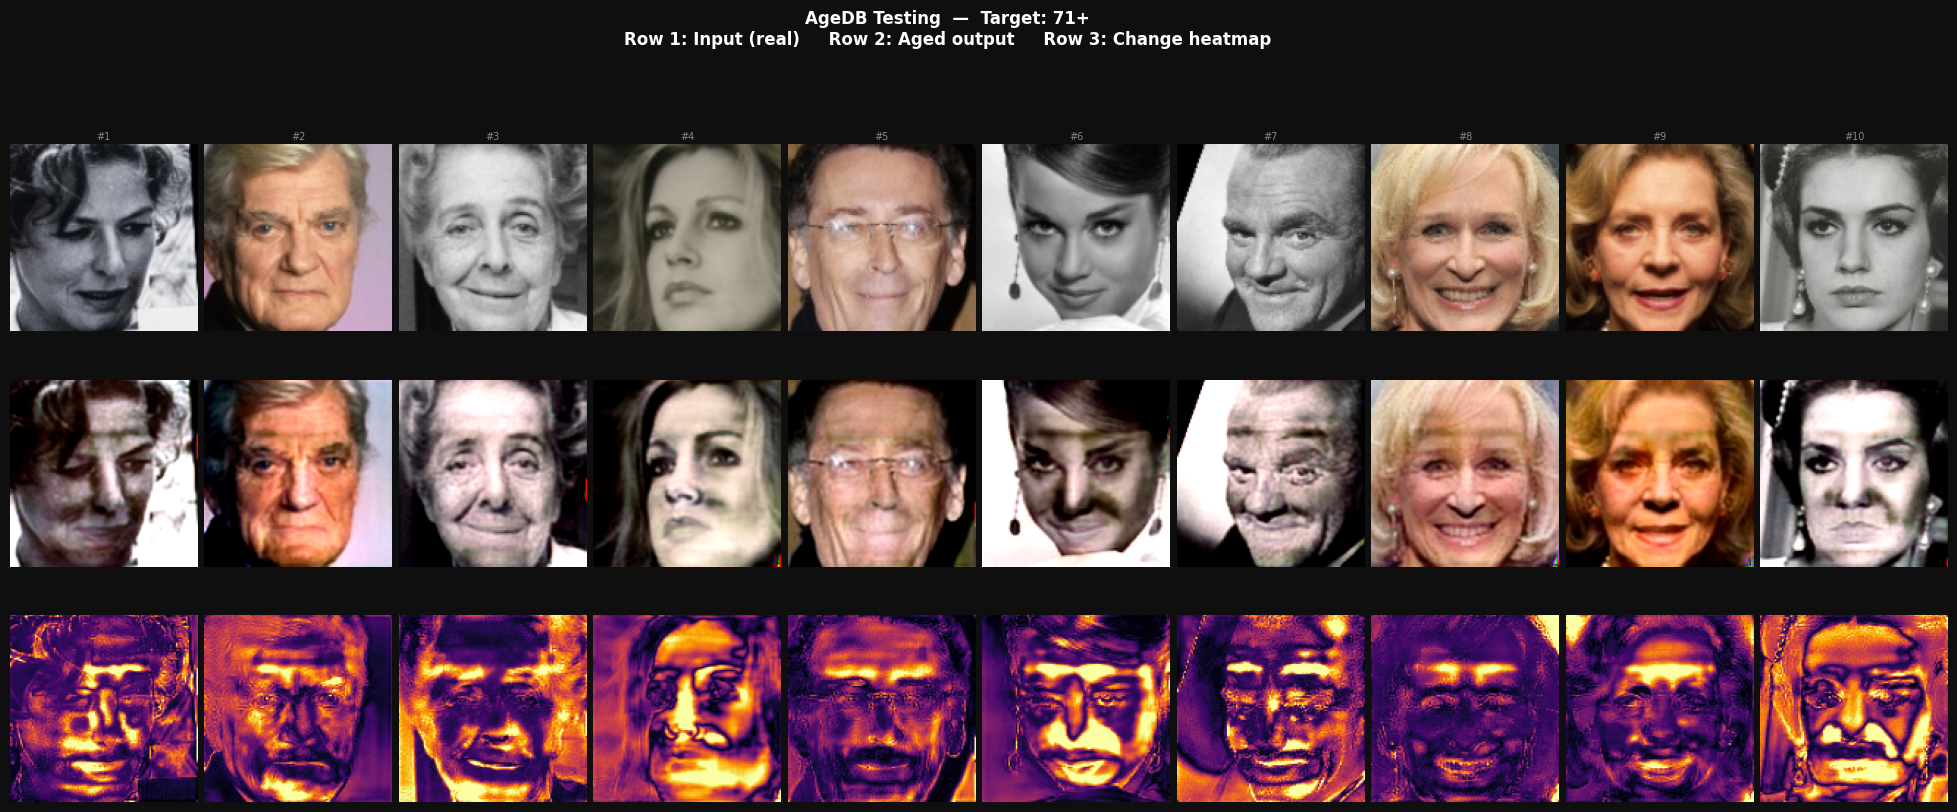

Saved → /content/drive/MyDrive/FaceAgingProject/test_results/test_results.png


In [ ]:
import torchvision.transforms.functional as TF

def enhance_aged(img_np):
    # img_np: (H, W, 3) numpy in [0, 1]
    t = torch.tensor(img_np).permute(2, 0, 1).float()   # (3, H, W)
    t = TF.adjust_contrast(t,   contrast_factor=1.3)
    t = TF.adjust_sharpness(t,  sharpness_factor=1.5)
    t = TF.adjust_saturation(t, saturation_factor=1.2)
    return t.permute(1, 2, 0).numpy().clip(0, 1)         # (H, W, 3)

n   = min(10, len(all_real))
idx = np.random.choice(len(all_real), n, replace=False)

fig, axes = plt.subplots(3, n, figsize=(2.5 * n, 9))
fig.patch.set_facecolor('#0f0f0f')

fig.suptitle(
    f'AgeDB Testing  —  Target: {AGE_LABELS[TARGET_GROUP]}\n'
    'Row 1: Input (real)     Row 2: Aged output     Row 3: Change heatmap',
    fontsize=12, fontweight='bold', color='white', y=1.01
)

ROW_LABELS  = ['Real', AGE_LABELS[TARGET_GROUP], 'Δ Map']
ROW_COLORS  = ['#5b9bd5', '#e07b54', '#e0a030']

for col, i in enumerate(idx):
    real_img  = all_real[i]
    aged_img  = enhance_aged(all_aged[i])   # enhanced for display only
    diff      = np.abs(all_aged[i] - all_real[i]).mean(axis=-1)
    heatmap   = (diff * 5).clip(0, 1)

    imgs   = [real_img, aged_img, heatmap]
    cmaps  = [None, None, 'inferno']

    for row in range(3):
        ax = axes[row, col]
        ax.imshow(imgs[row], cmap=cmaps[row])
        ax.axis('off')
        ax.set_facecolor('#0f0f0f')

        # top row gets the column number, leftmost column gets row label
        if col == 0:
            ax.set_ylabel(
                ROW_LABELS[row], fontsize=8,
                color=ROW_COLORS[row], rotation=90,
                labelpad=4, va='center'
            )
        if row == 0:
            ax.set_title(f'#{col+1}', fontsize=7, color='#888888', pad=3)

        # thin colored border per row
        for spine in ax.spines.values():
            spine.set_edgecolor(ROW_COLORS[row])
            spine.set_linewidth(0.6)
            spine.set_visible(True)

plt.subplots_adjust(wspace=0.04, hspace=0.06)
out = os.path.join(RESULTS_PATH, 'test_results.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'Saved → {out}')

In [ ]:
# Generate all missing age groups
print('Generating all 8 age groups...')
all_aged_by_group = {}

encoder.eval(); age_embedder.eval(); G.eval()

with torch.no_grad():
    for g in range(NUM_CLASSES):
        group_imgs = []
        for imgs, fnames in tqdm(agedb_loader, desc=f'Group {g} ({AGE_LABELS[g]})'):
            imgs = imgs.to(device)
            B    = imgs.size(0)
            tgt  = torch.full((B,), g, dtype=torch.long, device=device)
            _, id_vec = encoder(imgs)
            style     = age_embedder(tgt, id_vec)
            aged      = G(imgs, style)
            group_imgs.extend(denorm(aged))
        all_aged_by_group[g] = np.array(group_imgs)
        np.save(os.path.join(GUI_SAVE_PATH, f'aged_group_{g}.npy'), all_aged_by_group[g])
        print(f'  ✔ aged_group_{g}.npy  ({AGE_LABELS[g]})')

print('\n✅ All 8 groups saved!')

Generating all 8 age groups...


Group 0 (0-10): 100%|██████████| 32/32 [03:00<00:00,  5.63s/it]


  ✔ aged_group_0.npy  (0-10)


Group 1 (11-20): 100%|██████████| 32/32 [02:56<00:00,  5.52s/it]


  ✔ aged_group_1.npy  (11-20)


...

  ✔ aged_group_5.npy  (51-60)


Group 6 (61-70): 100%|██████████| 32/32 [03:09<00:00,  5.91s/it]


  ✔ aged_group_6.npy  (61-70)


Group 7 (71+): 100%|██████████| 32/32 [02:50<00:00,  5.33s/it]


  ✔ aged_group_7.npy  (71+)

✅ All 8 groups saved!


## 10. Aging Progression — All 8 Groups

Picks one face and ages it through every group. Also applies Gaussian temporal blending (from your original file) for a smoother transition.

## 11. Evaluation — CSIM (Cosine Identity Similarity)

Uses the **ArcFace** embedder (already loaded, frozen) to measure how much identity is preserved between real and aged image.
- Score > 0.7 = Excellent
- Score > 0.5 = Good
- Score < 0.5 = Poor

In [ ]:
def get_arcface_features(imgs_np):
    # imgs_np: numpy (N, H, W, 3) in [0, 1]
    # Returns: numpy (N, 512) L2-normalised embeddings via ArcFaceNet
    feats = []
    arcface.eval()
    with torch.no_grad():
        for i in range(0, len(imgs_np), BATCH_SIZE):
            batch = imgs_np[i : i + BATCH_SIZE]
            tensors = torch.stack([
                T.Compose([
                    T.ToTensor(),
                    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
                ])(Image.fromarray((img * 255).astype(np.uint8)))
                for img in batch
            ]).to(device)
            feats.append(arcface(tensors).cpu().numpy())
    return np.concatenate(feats)

print('Computing CSIM...')
real_feats = get_arcface_features(all_real)
aged_feats = get_arcface_features(all_aged)

# Cosine similarity - vectors are already L2-normalised by ArcFaceNet
csim_scores = (real_feats * aged_feats).sum(axis=1)
mean_csim   = float(csim_scores.mean())
std_csim    = float(csim_scores.std())

print(f'CSIM  mean : {mean_csim:.4f}  std : {std_csim:.4f}')
print(f'  > 0.7 = Excellent | > 0.5 = Good | < 0.5 = Poor')


Computing CSIM...
CSIM  mean : 0.8795  std : 0.0573
  > 0.7 = Excellent | > 0.5 = Good | < 0.5 = Poor


## 12. Evaluation — FID (Fréchet Inception Distance)

Measures image realism. Lower is better.
- FID < 50 = Good
- FID < 100 = Acceptable
- FID > 100 = Poor

In [ ]:
inception_model = models.inception_v3(
    weights=Inception_V3_Weights.DEFAULT,
    transform_input=False
)
inception_model.fc = nn.Identity()
inception_model     = inception_model.to(device).eval()
for p in inception_model.parameters():
    p.requires_grad = False

inception_tf = T.Compose([
    T.Resize((299, 299)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

def get_inception_features(imgs_np):
    feats = []
    with torch.no_grad():
        for i in range(0, len(imgs_np), BATCH_SIZE):
            batch = imgs_np[i : i + BATCH_SIZE]
            tensors = torch.stack([
                inception_tf(Image.fromarray((img * 255).astype(np.uint8)))
                for img in batch
            ]).to(device)
            feats.append(inception_model(tensors).cpu().numpy())
    return np.concatenate(feats)

def compute_fid(real_f, fake_f):
    mu_r, sigma_r = real_f.mean(0), np.cov(real_f, rowvar=False)
    mu_f, sigma_f = fake_f.mean(0), np.cov(fake_f, rowvar=False)
    diff    = mu_r - mu_f
    covmean = linalg.sqrtm(sigma_r @ sigma_f)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma_r + sigma_f - 2 * covmean))

print('Computing FID...')
real_inc = get_inception_features(all_real)
aged_inc = get_inception_features(all_aged)
fid      = compute_fid(real_inc, aged_inc)

print(f'FID Score : {fid:.2f}')
print(f'  < 50 = Good | < 100 = Acceptable | > 100 = Poor')

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:01<00:00, 99.5MB/s]


Computing FID...
FID Score : 51.10
  < 50 = Good | < 100 = Acceptable | > 100 = Poor


## 13. Final Report

In [ ]:
print('=' * 50)
print('    FACE AGING GAN — TEST EVALUATION REPORT')
print('=' * 50)
print(f'  Dataset        : AgeDB-30 ({len(all_real)} images)')
print(f'  Target group   : {TARGET_GROUP}  ({AGE_LABELS[TARGET_GROUP]})')
print(f'  Resolution     : {IMG_SIZE}x{IMG_SIZE}')
print(f'  CSIM           : {mean_csim:.4f} ± {std_csim:.4f}')
print(f'  FID            : {fid:.2f}')
print('=' * 50)

report = (
    f'Dataset      : AgeDB-30\n'
    f'Samples      : {len(all_real)}\n'
    f'Target group : {TARGET_GROUP} ({AGE_LABELS[TARGET_GROUP]})\n'
    f'CSIM         : {mean_csim:.4f} +/- {std_csim:.4f}\n'
    f'FID          : {fid:.2f}\n'
)
rpath = os.path.join(RESULTS_PATH, 'eval_report.txt')
with open(rpath, 'w') as f:
    f.write(report)
print(f'Report saved → {rpath}')

print('\nOutput files:')
for fn in sorted(os.listdir(RESULTS_PATH)):
    print(f'  {fn}')

    FACE AGING GAN — TEST EVALUATION REPORT
  Dataset        : AgeDB-30 (500 images)
  Target group   : 7  (71+)
  Resolution     : 128x128
  CSIM           : 0.8795 ± 0.0573
  FID            : 51.10
Report saved → /content/drive/MyDrive/FaceAgingProject/test_results/eval_report.txt

Output files:
  aging_progression.png
  eval_report.txt
  test_results.png


In [ ]:
BASE_PATH    = '/content/drive/MyDrive/FaceAgingProject'
MODEL_PATH   = '/content/drive/MyDrive/FaceAgingProject/final_models/final_model_epoch70.pth'

AGEDB_PATH   = '/content/drive/MyDrive/agedb_30_112x112/'
PAIRS_FILE   = '/content/drive/MyDrive/agedb_30_ann.txt'
RESULTS_PATH = '/content/drive/MyDrive/FaceAgingProject/test_results/'
GUI_SAVE_PATH = '/content/drive/MyDrive/FaceAgingProject/gui_data/'

os.makedirs(RESULTS_PATH, exist_ok=True)
os.makedirs(GUI_SAVE_PATH, exist_ok=True)

In [ ]:
# ════════════════════════════════════════════════════════════════
#  SAVE ALL OUTPUTS FOR GUI
# ════════════════════════════════════════════════════════════════
import pickle, json

print('💾 Saving everything for GUI...')

# ── 1. Save model weights (lightweight — just state dicts) ──────
torch.save({
    'encoder':      encoder.state_dict(),
    'age_embedder': age_embedder.state_dict(),
    'G':            G.state_dict(),
    'config': {
        'IMG_SIZE':     IMG_SIZE,
        'STYLE_DIM':    STYLE_DIM,
        'IDENTITY_DIM': IDENTITY_DIM,
        'NUM_CLASSES':  NUM_CLASSES,
    }
}, os.path.join(GUI_SAVE_PATH, 'gui_model_weights.pth'))
print('  ✔ gui_model_weights.pth')

# ── 2. Save generated images (all_real + all_aged_by_group) ─────
np.save(os.path.join(GUI_SAVE_PATH, 'all_real.npy'), all_real)
print('  ✔ all_real.npy')

for g in range(NUM_CLASSES):
    np.save(os.path.join(GUI_SAVE_PATH, f'aged_group_{g}.npy'), all_aged_by_group[g])
print('  ✔ aged_group_0.npy  ...  aged_group_7.npy')

# ── 3. Save filenames list ───────────────────────────────────────
with open(os.path.join(GUI_SAVE_PATH, 'filenames.json'), 'w') as f:
    json.dump(all_fnames, f)
print('  ✔ filenames.json')

# ── 4. Save evaluation metrics ──────────────────────────────────
metrics = {
    'csim_mean':   mean_csim,
    'csim_std':    std_csim,
    'fid':         fid,
    'n_samples':   len(all_real),
    'img_size':    IMG_SIZE,
    'age_labels':  AGE_LABELS,
    'target_group': TARGET_GROUP,
}
with open(os.path.join(GUI_SAVE_PATH, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('  ✔ metrics.json')

# ── 5. Save CSIM per-sample scores ──────────────────────────────
np.save(os.path.join(GUI_SAVE_PATH, 'csim_scores.npy'), csim_scores)
print('  ✔ csim_scores.npy')

# ── 6. Save config as JSON (so GUI can read without torch) ──────
config = {
    'IMG_SIZE':      IMG_SIZE,
    'STYLE_DIM':     STYLE_DIM,
    'IDENTITY_DIM':  IDENTITY_DIM,
    'NUM_CLASSES':   NUM_CLASSES,
    'BATCH_SIZE':    BATCH_SIZE,
    'AGE_LABELS':    AGE_LABELS,
    'BASE_PATH':     BASE_PATH,
    'MODEL_PATH':    MODEL_PATH,
    'GUI_SAVE_PATH': GUI_SAVE_PATH,
    'RESULTS_PATH':  RESULTS_PATH,
}
with open(os.path.join(GUI_SAVE_PATH, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print('  ✔ config.json')

# ── Summary ─────────────────────────────────────────────────────
print()
print('=' * 55)
print('  ALL FILES SAVED TO:')
print(f'  {GUI_SAVE_PATH}')
print('=' * 55)
print()
saved = sorted(os.listdir(GUI_SAVE_PATH))
total_mb = 0
for fn in saved:
    fp = os.path.join(GUI_SAVE_PATH, fn)
    mb = os.path.getsize(fp) / 1e6
    total_mb += mb
    print(f'  {fn:<35}  {mb:6.1f} MB')
print(f'  {"─"*44}')
print(f'  {"TOTAL":<35}  {total_mb:6.1f} MB')
print()
print('Load these in your GUI notebook with:')
print(f'  GUI_SAVE_PATH = "{GUI_SAVE_PATH}"')

💾 Saving everything for GUI...
  ✔ gui_model_weights.pth
  ✔ all_real.npy
  ✔ aged_group_0.npy  ...  aged_group_7.npy
  ✔ filenames.json
  ✔ metrics.json
  ✔ csim_scores.npy
  ✔ config.json

  ALL FILES SAVED TO:
  /content/drive/MyDrive/FaceAgingProject/gui_data/

  aged_group_0.npy                       98.3 MB
  aged_group_1.npy                       98.3 MB
  aged_group_2.npy                       98.3 MB
  aged_group_3.npy                       98.3 MB
  aged_group_4.npy                       98.3 MB
  aged_group_5.npy                       98.3 MB
  aged_group_6.npy                       98.3 MB
  aged_group_7.npy                       98.3 MB
  all_real.npy                           98.3 MB
  config.json                             0.0 MB
  csim_scores.npy                         0.0 MB
  filenames.json                          0.0 MB
  gui_model_weights.pth                 201.5 MB
  metrics.json                            0.0 MB
  ────────────────────────────────────────────
 